In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.family'] = 'Arial'  # Set global font to Arial
#import numpy as np
import cartopy.feature as feature

In [8]:
#path_sm = '/g/data/jk72/sm3719/'
#path_cmip = 'cmip6'
#path_ds = '/pictrl/CSIRO-MK3-6-0/climate_index/eof/IOBM-IOD/eof2_CSIRO-Mk3-6-0-iobm_kave.nc'

#xr.open_dataset(path_sm + path_cmip)

In [9]:
ds1=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/NAO/Regression_SLP_spatial_pattern_NAO_ERA5-23models.nc')
ds2=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/NAO/Regression_SLP_spatial_pattern_NAO_MMM.nc')

NAO1=ds1['SLOPE'][0,:,:]
NAO2=ds1['SLOPE'][1,:,:]
NAO3=ds1['SLOPE'][2,:,:]
NAO4=ds1['SLOPE'][3,:,:]
NAO5=ds1['SLOPE'][4,:,:]
NAO6=ds1['SLOPE'][5,:,:]
NAO7=ds1['SLOPE'][6,:,:]
NAO8=ds1['SLOPE'][7,:,:]
NAO9=ds1['SLOPE'][8,:,:]
NAO10=ds1['SLOPE'][9,:,:]
print(ds1.coords)
#print(ds9)
#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds1.coords)
LON = ds1.LON.data
LAT = ds1.LAT.data
LON=np.linspace(-90,40,131)
LAT=np.linspace(20,80,60)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)


Coordinates:
  * time     (time) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 37.0 38.0 39.0 40.0
  * LAT      (LAT) float64 480B 20.44 21.44 22.44 23.43 ... 77.28 78.28 79.28
Coordinates:
  * time     (time) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 37.0 38.0 39.0 40.0
  * LAT      (LAT) float64 480B 20.44 21.44 22.44 23.43 ... 77.28 78.28 79.28


In [10]:
NAO11=ds1['SLOPE'][10,:,:]
NAO12=ds1['SLOPE'][11,:,:]
NAO13=ds1['SLOPE'][12,:,:]
NAO14=ds1['SLOPE'][13,:,:]
NAO15=ds1['SLOPE'][14,:,:]
NAO16=ds1['SLOPE'][15,:,:]
NAO17=ds1['SLOPE'][16,:,:]
NAO18=ds1['SLOPE'][17,:,:]
NAO19=ds1['SLOPE'][18,:,:]
NAO20=ds1['SLOPE'][19,:,:]
NAO21=ds1['SLOPE'][20,:,:]
NAO22=ds1['SLOPE'][21,:,:]
NAO23=ds1['SLOPE'][22,:,:]
NAO24=ds1['SLOPE'][23,:,:]
NAO25=ds2['MMM'][:,:]


In [11]:
datasets = [
    (NAO1, "(a) ERA5 (EOF1-33.1%)"),
    (NAO2, "(b) CanESM5 (EOF1-31.1%)"),
    (NAO3, "(c) HadGEM3-GC31-LL (EOF1-33.7%)"),
    (NAO4, "(d) EC-Earth3-CC (EOF1-32.5%)"),
    (NAO5, "(e) CMCC-CM2-SR5 (EOF1-30.7%)"),
    (NAO6, "(f) CNRM-CM6-1 (EOF1-33.5%)"),
    (NAO7, "(g) GISS-E2-1-G (EOF1-33.4%)"),
    (NAO8, "(h) CMCC-ESM2 (EOF1-29.8%)"),
    (NAO9, "(i) EC-Earth3 (EOF1-33.0%)"),
    (NAO10, "(j) E3SM1-0 (EOF1-34.4%)"),
    (NAO11, "(k) MIROC6 (EOF1-32.2%)"),
    (NAO12, "(l) MRI-ESM2-0 (EOF1-34.0%)"),
    (NAO13, "(m) HadGEM3-GC31-MM (EOF1-31.6%)"),
    (NAO14, "(n) BCC-CSM2-MR (EOF1-35.5%)"),
    (NAO15, "(o) IPSL-CM6A-LR (EOF1-33.6%)"),
    (NAO16, "(p) MPI-ESM1-2-HR (EOF1-32.9%)"),
    (NAO17, "(q) ACCESS-ESM1-5 (EOF1-28.6%)"),
    (NAO18, "(r) ACCESS-CM2 (EOF1-34.3%)"),
    (NAO19, "(s) CESM2 (EOF1-33.6%)"),
    (NAO20, "(t) GFDL-CM4 (EOF1-31.7%)"),
    (NAO21, "(u) CIESM (EOF1-31.4%)"),
    (NAO22, "(v) FGOALS-g3 (EOF1-33.9%)"),
    (NAO23, "(w) SAM0-UNICON (EOF1-28.9%)"),
    (NAO24, "(x) CNRM-ESM2-1 (EOF1-34.7%)"),
    (NAO25, "(y) MMM")
]

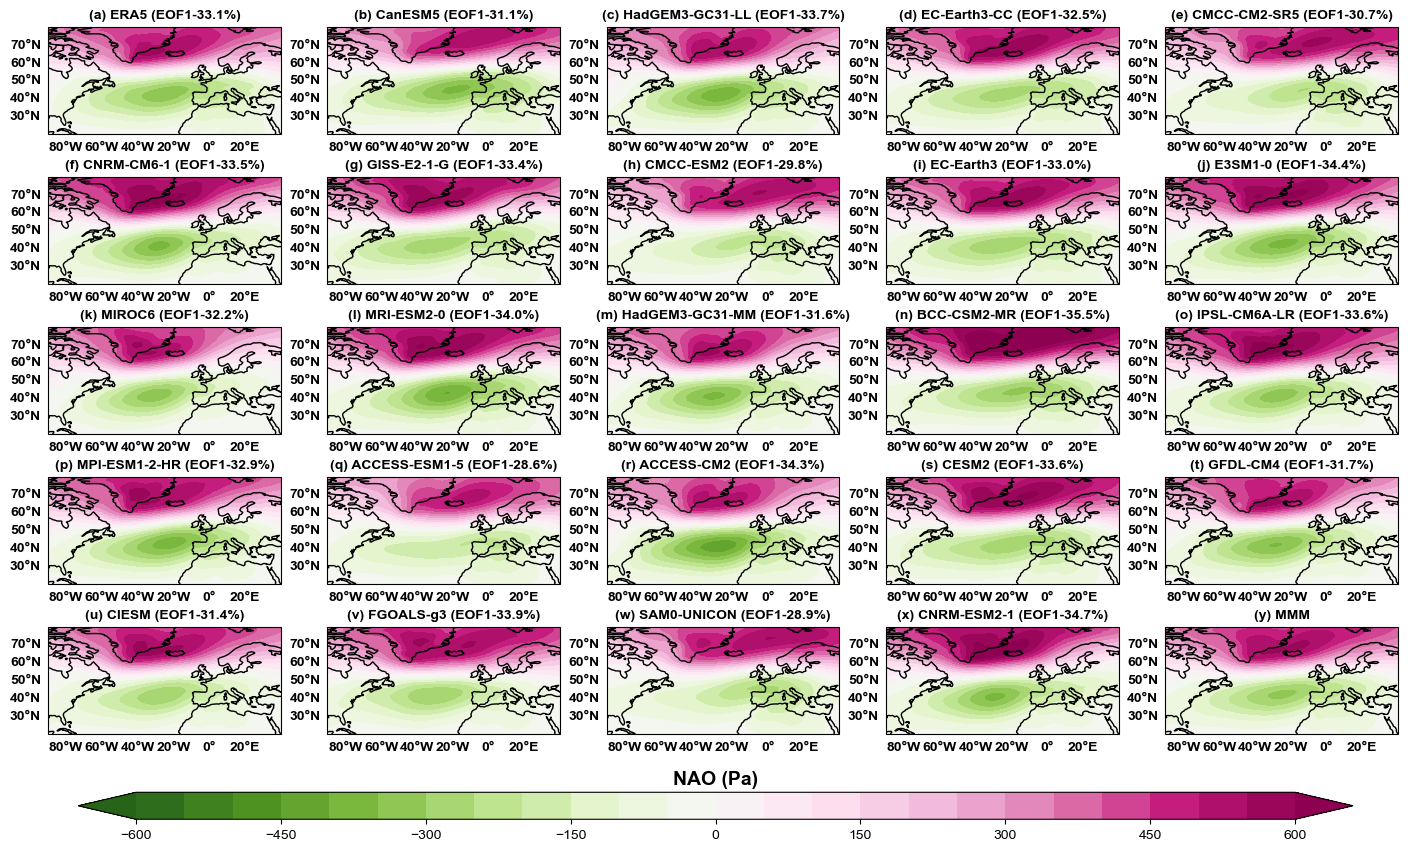

In [19]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=0)
clevs = np.arange(-600.0, 650.0, 50.0)

# Create figure
fig = plt.figure(figsize=(15, 13.5))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(
        LON, LAT, data, levels=clevs, cmap=plt.cm.PiYG_r, 
        transform=ccrs.PlateCarree(), extend='both'
    )
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
#    ax.annotate(annotation, xy=(0.5, -0.23), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('NAO (Pa)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('/g/data/jk72/sm3719/cmip6/ESSD/climate_mode/panel25_regression_NAO_models_observations_new.png', dpi=600)
plt.show()